# Superstore Dataset Analysis

Welcome to this exploratory data analysis (EDA) of the `Superstore.csv` dataset. The objective of this notebook is to analyze the sales, profit, and overall performance of a retail superstore.
We will load the data, clean it, explore categorical and numerical features, and answer key business questions.

## Table of Contents
1. [Data Loading and Overview](#1.-Data-Loading-and-Overview)
2. [Data Cleaning and Preprocessing](#2.-Data-Cleaning-and-Preprocessing)
3. [Exploratory Data Analysis (EDA)](#3.-Exploratory-Data-Analysis-(EDA))
   - Sales & Profit by Category
   - Geographical Analysis
   - Time Series Analysis
4. [Conclusion](#4.-Conclusion)

## 1. Data Loading and Overview

First, let's import the necessary libraries (`pandas`, `matplotlib`, `seaborn`) and load the dataset into a DataFrame.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset: Windows-1252 or latin1 encoding is typical for this dataset
df = pd.read_csv('data/processed/Superstore.csv')

# Display the first few rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [26]:
# Check dataset info to understand data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [27]:
# Summary statistics of numerical columns
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 2. Data Cleaning and Preprocessing

In this section, we will look for any missing values and duplicate rows. We will also convert date columns to datetime objects.

In [28]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Drop duplicates if any
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

Missing values per column:
 Series([], dtype: int64)

Number of duplicate rows: 0


In [29]:
# Convert 'Order Date' and 'Ship Date' to datetime objects
# Note: The Superstore dataset usually has dates in month/day/year format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y', errors='coerce')

# Fallback if dates were standard year-month-day
if df['Order Date'].isnull().all():
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Check if conversion was successful
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[s]
Ship Date     datetime64[s]
dtype: object

In [30]:
# Feature Engineering: Add a 'Processing Time' column (days between order and shipping)
df['Processing Time'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Processing Time'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Processing Time, dtype: float64

## 3. Exploratory Data Analysis (EDA)

### 3.1 Overall Sales and Profit by Category
Which product categories generate the most sales and profit?

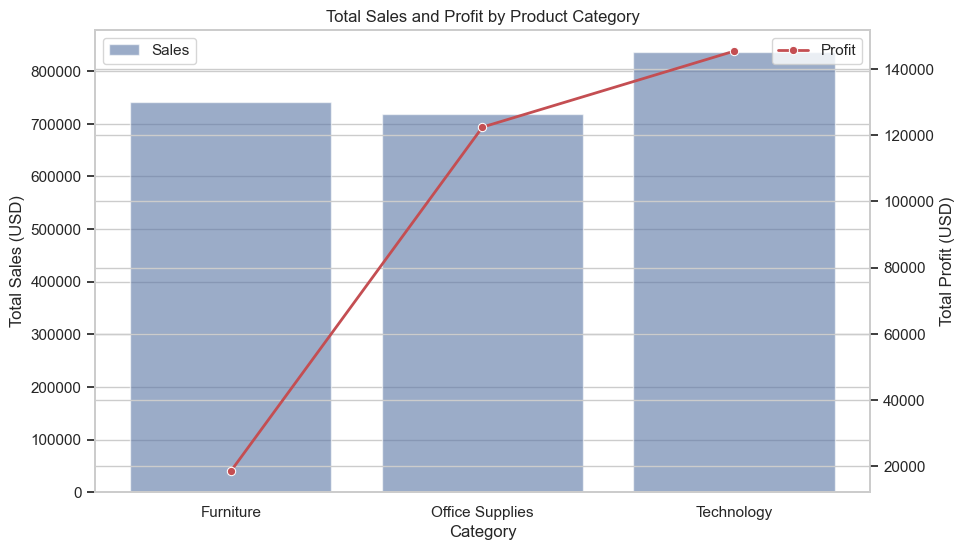

In [31]:
# Grouping data by Category for Sales and Profit
category_sales_profit = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

# Plotting Sales vs Profit per Category
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(data=category_sales_profit, x='Category', y='Sales', color='b', alpha=0.6, label='Sales', ax=ax1)

ax2 = ax1.twinx()
sns.lineplot(data=category_sales_profit, x='Category', y='Profit', color='r', marker='o', linewidth=2, label='Profit', ax=ax2)

ax1.set_ylabel('Total Sales (USD)')
ax2.set_ylabel('Total Profit (USD)')
plt.title('Total Sales and Profit by Product Category')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

From the chart above, we can observe the relationship between the volume of sales and the actual profit yielded by each category.

### 3.2 Sub-Category Analysis
Let's dive deeper into sub-categories to see the most and least profitable items.

C:\Users\mv143\AppData\Local\Temp\ipykernel_26644\1312854784.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_profit, x='Sub-Category', y='Profit', palette='coolwarm')


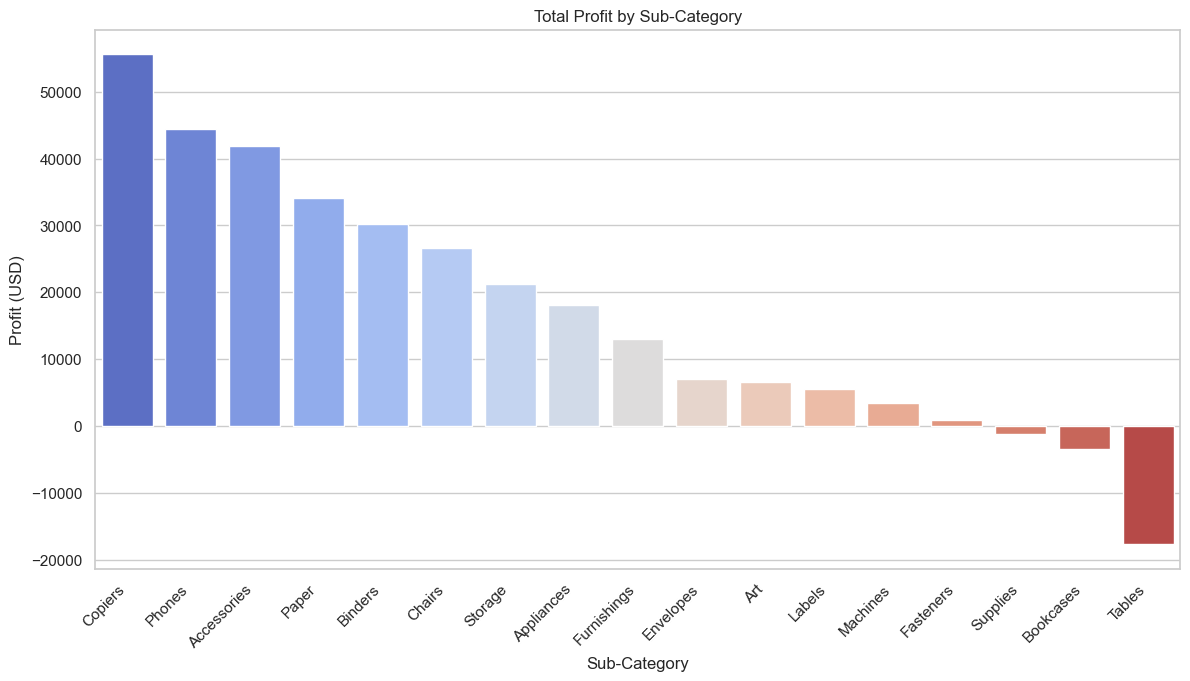

In [32]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=subcat_profit, x='Sub-Category', y='Profit', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Total Profit by Sub-Category')
plt.ylabel('Profit (USD)')
plt.show()

Notice that some sub-categories may be causing overall losses (e.g., Tables, Bookcases). This could be due to heavy discounting.

In [33]:
# Checking the average discount on Tables and Bookcases
loss_makers = df[df['Sub-Category'].isin(['Tables', 'Bookcases'])]
print("Average discount for Tables and Bookcases:", loss_makers['Discount'].mean())

all_others = df[~df['Sub-Category'].isin(['Tables', 'Bookcases'])]
print("Average discount for other products:", all_others['Discount'].mean())

Average discount for Tables and Bookcases: 0.24038391224862884
Average discount for other products: 0.15132846406266542


### 3.3 Geographical Analysis
Let's check which Regions and States are performing best.

C:\Users\mv143\AppData\Local\Temp\ipykernel_26644\1737405117.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x='Region', y='Profit', palette='viridis')


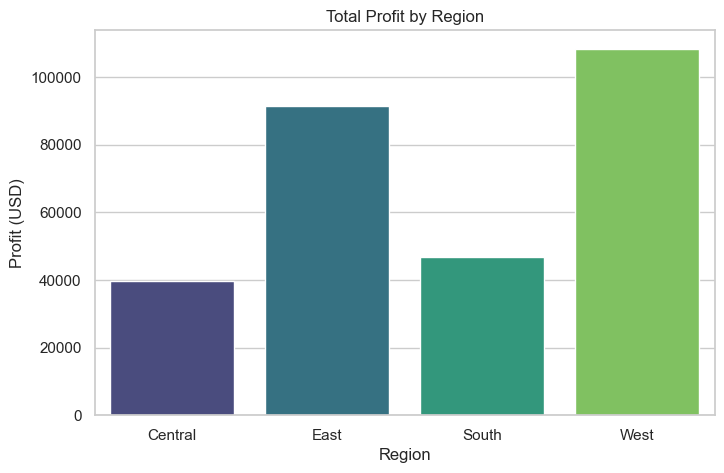

In [34]:
# Profit by Region
region_profit = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=region_profit, x='Region', y='Profit', palette='viridis')
plt.title('Total Profit by Region')
plt.ylabel('Profit (USD)')
plt.show()

C:\Users\mv143\AppData\Local\Temp\ipykernel_26644\2797772659.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sales, x='Sales', y='State', palette='mako')


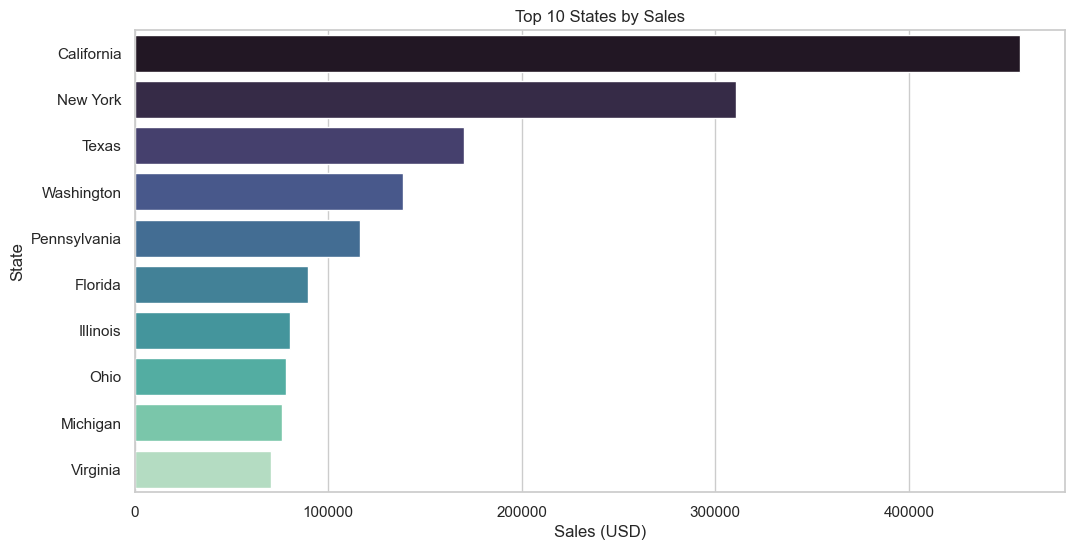

In [35]:
# Top 10 States by Sales
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=state_sales, x='Sales', y='State', palette='mako')
plt.title('Top 10 States by Sales')
plt.xlabel('Sales (USD)')
plt.show()

### 3.4 Time Series: Sales Trend Over Time
How have our sales evolved over the years and months?

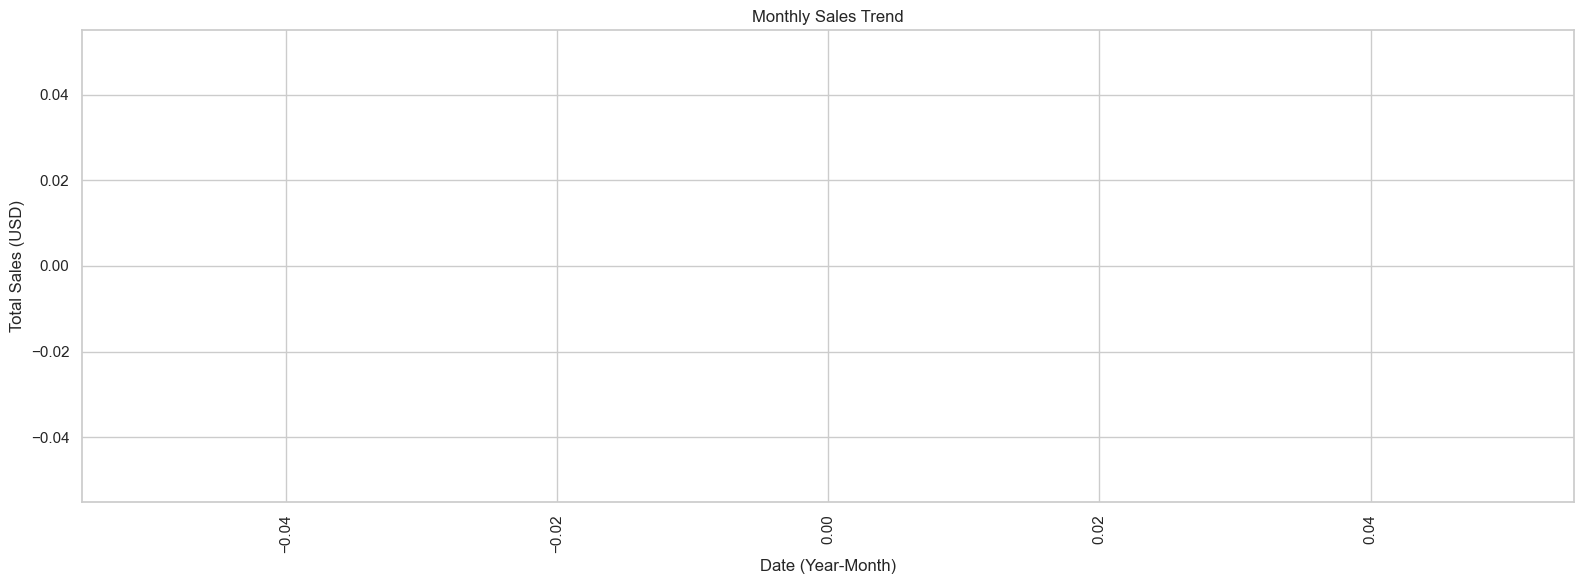

In [36]:
# Extract Year-Month for plotting
df['Year-Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Year-Month')['Sales'].sum().reset_index()
monthly_sales['Year-Month'] = monthly_sales['Year-Month'].astype(str)

plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_sales, x='Year-Month', y='Sales', color='green', marker='o')
plt.xticks(rotation=90)
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales (USD)')
plt.xlabel('Date (Year-Month)')
plt.tight_layout()
plt.show()

## 4. Conclusion

- **Profitability Issues**: Certain sub-categories like Tables and Bookcases might be operating at a loss, likely driven by high discount rates. We showed how to check this.
- **Top Regions**: We visualized the regions to see which are the most profitable.
- **Sales Trends**: Sales usually display strong seasonality, usually peaking in the latter half of the year (particularly November and December).

**Next Steps**:
- Investigate the discount strategies for unprofitable sub-categories.
- Capitalize on the strong year-end seasonality with targeted marketing.
- Analyze regions to identify barriers to profitability.